# Week6_Spatial Data 2

After this week's lesson you should be able to:
- Create GeoDataFrames with CSVs.
- Create choropleth map(s)
- Perform overlay operations such as union and intersect
- Check for containment or intersection between multiple geometries
- Find centroids and convex hulls 
- Find distances to points

This week's lessons are adapted from:
- [Automating GIS Processes Lesson 1](https://autogis-site.readthedocs.io/en/latest/lessons/lesson-1/overview.html)
- [The Shapely Documentation](https://shapely.readthedocs.io/en/stable/manual.html)
- [Spatial Data Programming with Python](https://geobgu.xyz/)

In [1]:
# We are going to start importing the libraries we need
# all in one cell. 
# It is a good practice to keep all the imports in one cell so that
# we can easily see what libraries we are using in the notebook.

# Import geopandas module and assign it the nickname gpd
import geopandas as gpd

import pandas as pd
import numpy as np
import seaborn as sns

# Import the pyplot module from matplotlib and assign it the nickname plt
from matplotlib import pyplot as plt

# Ensures plots are displayed inline within the Jupyter Notebook
%matplotlib inline

# Warnings: Suppresses unnecessary warning messages to keep the output clean
import warnings
warnings.filterwarnings("ignore")


## 1. Geometric Objects
There are three kinds of geometric objects: 
- **points**: Points are represented by a single coordinate are defined using the `Point` class.
- **lines**: Connecting points together creates a line
- **polygons**: Connecting lines in an enclosed area creates a polygon. 

In `Shapely` and spatial data structures like GeoJSON, these basic geometries can be extended into more complex structures to handle multiple features or combinations of different geometries. `Shapely` is a Python library for geometric operations and spatial analysis.

<figure class="image">
<img src="https://autogis-site.readthedocs.io/en/latest/_images/simple-features_595x500px.svg" alt="drawing" width="500" style="display: block; margin: 0 auto"/>
 <figcaption>
    <center>Fundamental geometric objects (‘simple features’) that can be used in Python with 
    <a href="https://shapely.readthedocs.io/en/stable/" target="_blank">Shapely</a>. Figures by M. W. Toews; cf. Wikipedia’s article on GeoJSON
    </center>
</figcaption>
</figure>

From the above, we can see that: 
- The `LineString` class is used to construct lines through a sequence of points.
- A polygon is just one or more LinearRings (you can have a polygon with a hole in the middle, which would require two LinearRings). 

To check the feature type of geometry column: 

In [115]:
stations = gpd.read_file('Subway Stations.zip')
stations.geom_type

0      Point
1      Point
2      Point
3      Point
4      Point
       ...  
468    Point
469    Point
470    Point
471    Point
472    Point
Length: 473, dtype: object

### 1.1 Geometric manipulations

1. `.boundary` returns the "border" of a geometry. If the geometry is a polygon, this method will return the border (a line), if the geometry is a line, this method will return a collection of points. If the geometry is a point, this method will return an empty result. 

In [127]:
neighborhoods.boundary

0      LINESTRING (-73.93213 40.72816, -73.93238 40.7...
1      LINESTRING (-73.95814 40.72440, -73.95772 40.7...
2      LINESTRING (-73.95024 40.70547, -73.94984 40.7...
3      LINESTRING (-73.92406 40.71411, -73.92404 40.7...
4      LINESTRING (-73.99103 40.69985, -73.99124 40.6...
                             ...                        
257    LINESTRING (-74.20058 40.57951, -74.19888 40.5...
258    LINESTRING (-74.05975 40.59385, -74.06013 40.5...
259    MULTILINESTRING ((-74.05051 40.56642, -74.0504...
260    LINESTRING (-74.08469 40.57148, -74.08595 40.5...
261    LINESTRING (-74.11747 40.55004, -74.11656 40.5...
Length: 262, dtype: geometry

<Axes: >

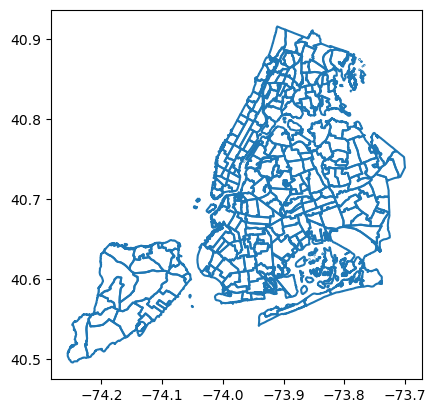

In [119]:
neighborhoods = gpd.read_file('NTA map.zip')
neighborhoods.boundary.plot()

2. `.centroid` in Shapely returns the geometric center (centroid) of a shape.
- It is the average of all points in the geometry.
- If applied to a Polygon or MultiPolygon, it returns a Point representing the centroid.
- For irregular shapes, it may be outside the shape.
- If applied to a LineString, it returns the midpoint of the line.

<img src="https://github.com/wenzhengli-etal/UrbanDataScience_4680_5680/blob/main/img/week6_cresent.png?raw=true" width="300" style="display: block; margin: auto;">


<Axes: >

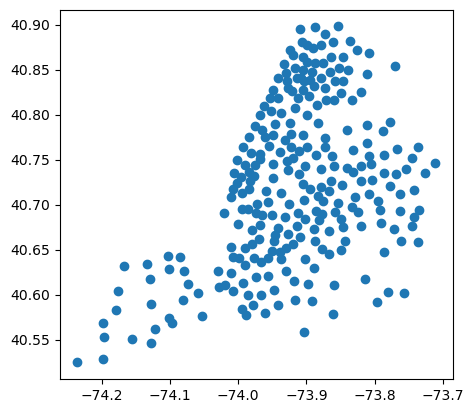

In [120]:
neighborhoods.centroid.plot()

3. `.buffer` returns the buffer of a geometry given a radius. 

<Axes: >

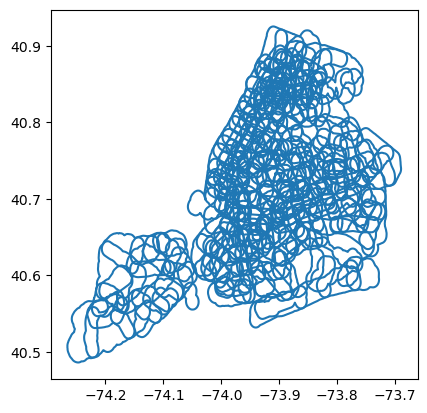

In [124]:
## I'm plotting the boundaries of the neighborhoods so you can see the buffer more easily. 
neighborhoods.buffer(0.01).boundary.plot()

4. `.dissolve` combines geometries that are touching. 

<Axes: >

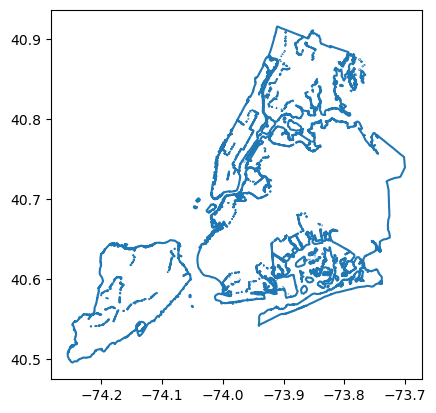

In [138]:
# Again, plotting the boundaries so you can see the dissolve more easily.
neighborhoods.dissolve().boundary.plot()

You can also dissolve by a particular category

<Axes: >

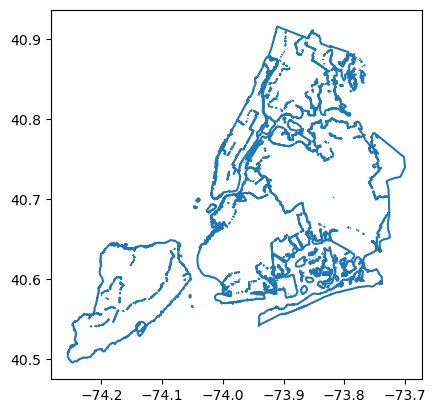

In [139]:
neighborhoods.dissolve(by='boroname').boundary.plot()

5. `.distance` Finds the distance between a point a the geometries in a geodataframe.

In [157]:
# Create a DataFrame with a single point's longitude & latitude
a_point_xy = pd.DataFrame({'longitude': [-73.971321], 'latitude':[40.776676] }) 

# Convert the DataFrame into a GeoDataFrame
a_point = gpd.GeoDataFrame(a_point_xy, 
                           geometry=gpd.points_from_xy(a_point_xy.longitude, a_point_xy.latitude), 
                           crs='EPSG:4326') 

# Compute the distance between the given point and all station points
stations.to_crs(3857).distance(a_point.to_crs(3857).iloc[0].geometry)

0       7195.247996
1       9090.894644
2       2602.385545
3      14080.720392
4      18515.676984
           ...     
468    29288.586793
469     4642.210546
470     1849.488156
471     2183.267293
472     2919.882213
Length: 473, dtype: float64

## 2. Making a new GeoDataFrame from a non-spatial file


It is quite common that our dataset is in the format of excel (.xlsx) or .csv but incorporate the coordinate system as two columns. We can easily turn this into a GeoDataFrame by transforming these lat/lng shapely `Points`, and further to shapefile. 

As an example: 
- download the CSV of [NYC Firehouses](https://data.cityofnewyork.us/Public-Safety/FDNY-Firehouse-Listing/hc8x-tcnd). (It's under **Export**.)
- Make sure this CSV is in the same folder as this notebook. 
- remove the date of download on the file name

In [5]:
# import the gdf_firehouse data and check
df_firehouse = pd.read_csv('FDNY_Firehouse_Listing_20250224.csv')
df_firehouse.head()

,FacilityName,FacilityAddress,Borough,Postcode,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
0,Engine 4/Ladder 15,42 South Street,Manhattan,10005,40.703694,-74.007717,101,1,7,1000867,1000350001,Battery Park City-Lower Manhattan
1,Engine 6,49 Beekman Street,Manhattan,10038,40.709971,-74.005395,101,1,1501,1001287,1000930030,Battery Park City-Lower Manhattan
2,Manhattan Borough Command/Battalion 1/Engine 7...,100 Duane Street,Manhattan,10007,40.715339,-74.006300,101,1,33,1001647,1001500025,SoHo-TriBeCa-Civic Center-Little Italy
3,Ladder 8,14 N. Moore Street,Manhattan,10013,40.719574,-74.006620,101,1,33,1002150,1001890035,SoHo-TriBeCa-Civic Center-Little Italy
4,Engine 9/Ladder 6,75 Canal Street,Manhattan,10002,40.715408,-73.992834,103,1,16,1003898,1003000030,Chinatown


In order to create a GeoDataFrame, we need all three components: **data/DF, CRS, and geometry** of the GeoDataFrame. We will use the `points_from_xy()` function to convert to gdf. This is basically using shapely `Points` under the hood. 

If your code reports error, try to run the following code to import Point from shapely package
- `from shapely.geometry import Point`

In [6]:
# Latitude coordinate for Global Coordinate System, WGS 1984, decimal degrees (EPSG 4326)
gdf_firehouse = gpd.GeoDataFrame(df_firehouse, 
                              geometry=gpd.points_from_xy(df_firehouse['Longitude'], df_firehouse['Latitude']),
                              crs='EPSG:4326')

In [7]:
# Voila
gdf_firehouse.head()

,FacilityName,FacilityAddress,Borough,Postcode,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA,geometry
0,Engine 4/Ladder 15,42 South Street,Manhattan,10005,40.703694,-74.007717,101,1,7,1000867,1000350001,Battery Park City-Lower Manhattan,POINT (-74.00772 40.70369)
1,Engine 6,49 Beekman Street,Manhattan,10038,40.709971,-74.005395,101,1,1501,1001287,1000930030,Battery Park City-Lower Manhattan,POINT (-74.00539 40.70997)
2,Manhattan Borough Command/Battalion 1/Engine 7...,100 Duane Street,Manhattan,10007,40.715339,-74.006300,101,1,33,1001647,1001500025,SoHo-TriBeCa-Civic Center-Little Italy,POINT (-74.00630 40.71534)
3,Ladder 8,14 N. Moore Street,Manhattan,10013,40.719574,-74.006620,101,1,33,1002150,1001890035,SoHo-TriBeCa-Civic Center-Little Italy,POINT (-74.00662 40.71957)
4,Engine 9/Ladder 6,75 Canal Street,Manhattan,10002,40.715408,-73.992834,103,1,16,1003898,1003000030,Chinatown,POINT (-73.99283 40.71541)


<Axes: >

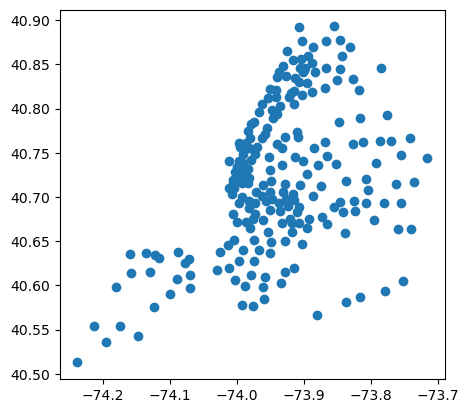

In [8]:
# plot the gdf_firehouse
gdf_firehouse.plot()

## 3. Choropleth map

A choropleth map is a type of thematic map where geographical areas (such as countries, states, or districts) are colored or shaded based on a data variable, such as population density, income levels, or election results. The color intensity represents different values, helping to visualize spatial patterns and distributions.

Now let us look at an example that visualize the mean housing price and the total counts of housing sales at the census tract in the borough of Manhattan. The maps adopts graduate color scheme, as prices and units are continuous values. The dataset comes from https://www.baruch.cuny.edu/confluence/display/geoportal/NYC+Geocoded+Real+Estate+Sales.  


In [22]:
# read the houisng data with the mean sale price and total sale counts
gdf_ManhanHousing = gpd.read_file('manha_housing.zip')
gdf_ManhanHousing.head(3)

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,count,price,geometry
0,36,061,023400,36061023400,234,Census Tract 234,G5020,S,108499,0,+40.8237337,-073.9386672,36.0,9.663828e+05,"POLYGON ((1000587.133 239536.218, 1000713.183 ..."
1,36,061,023501,36061023501,235.01,Census Tract 235.01,G5020,S,179045,0,+40.8289967,-073.9418352,35.0,2.123494e+06,"POLYGON ((999516.593 241317.491, 999642.366 24..."
2,36,061,023502,36061023502,235.02,Census Tract 235.02,G5020,S,41338,0,+40.8278881,-073.9389277,19.0,4.686665e+05,"POLYGON ((1000816.400 240595.500, 1000940.784 ..."


In [68]:
# check projection? 
gdf_ManhanHousing.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US Survey feet)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

Notice the following parameters in the maps: 
- column: the variable to plot (e.g., 'count', 'price')
- cmap: color scheme of the map (e.g., 'OrRd', 'coolwarm', see list here https://matplotlib.org/tutorials/colors/colormaps.html#palettable)
- **scheme**: categorization scheme (e.g., 'equal_interval', 'quantiles' or 'percentiles')
    - **equal_interval**: Class breaks at regular intervals along the number line at a set equivalent
range. Each class is used to represent an equivalent range of measured data values. **Suggested use: Uniformly distributed data with familiar data ranges.**
    - **quantiles**: Equal numbers of data observations are placed into each category. Data is classified into groups like Top 20%, Upper-Middle 20%, Middle 20%, Lower-Middle 20%, and Bottom 20%. **Suggested use: Evenly(Close to uniformly) distributed data and ordinal data.**
    - **natural_breaks**: Algorithmically optimal breaks are placed in data based on sums of deviations of means between individual classes. Maximizing between group variation while minimizing within group variation. **Suggested use: Clustered and Skewed data**
- k: number of categories
- **legend_kwds**: You can read the `matplotlib.pyplot.legend()` [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html#matplotlib.pyplot.legend) to get a better sense of all the possible ways to format the legend.

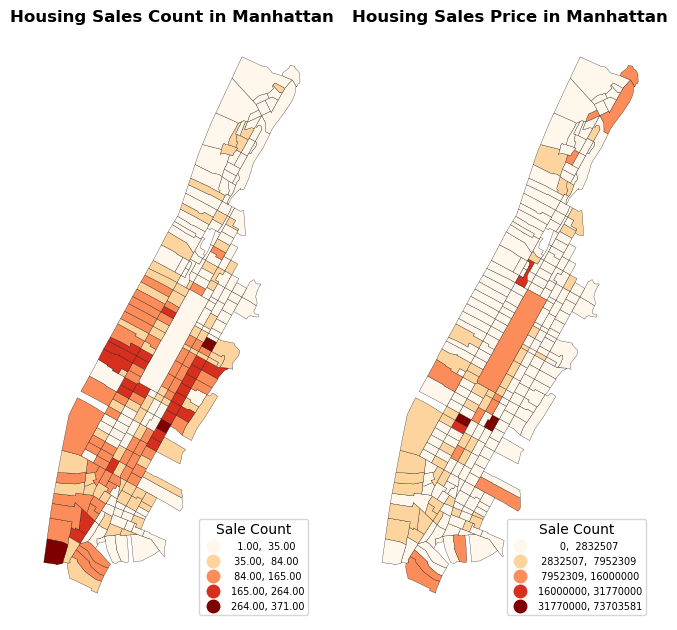

In [57]:
# initialize a plot
fig, ax = plt.subplots(1,2,figsize = (8,10))

# subplot for count
gdf_ManhanHousing.plot(ax = ax[0], 
                       column = "count",
                       cmap = "OrRd", 
                       scheme = "natural_breaks", 
                       k = 5, 
                       edgecolor='black', 
                       lw = 0.2, 
                       legend = True, 
                       legend_kwds = {"loc": 'lower right', 'title': 'Sale Count', 'title_fontsize': 10, 'fontsize': 7, 'frameon': True})
ax[0].axis('off')
ax[0].set_title("Housing Sales Count in Manhattan", fontsize=12, fontweight="bold")

# subplot for price
gdf_ManhanHousing.plot(ax = ax[1], 
                       column = "price",
                       cmap = "OrRd", 
                       scheme = "natural_breaks", 
                       k = 5, 
                       edgecolor='black', 
                       lw = 0.2, 
                       legend = True, 
                       legend_kwds = {"loc": 'lower right', 'title': 'Sale Count', 
                                      'title_fontsize': 10, 'fontsize': 7, 'frameon': True, 
                                      "fmt": "{:.0f}"})
ax[1].axis('off')
ax[1].set_title("Housing Sales Price in Manhattan", fontsize=12, fontweight="bold")

# save the figure
fig.savefig('manha_count_print_17.png', dpi = 200)

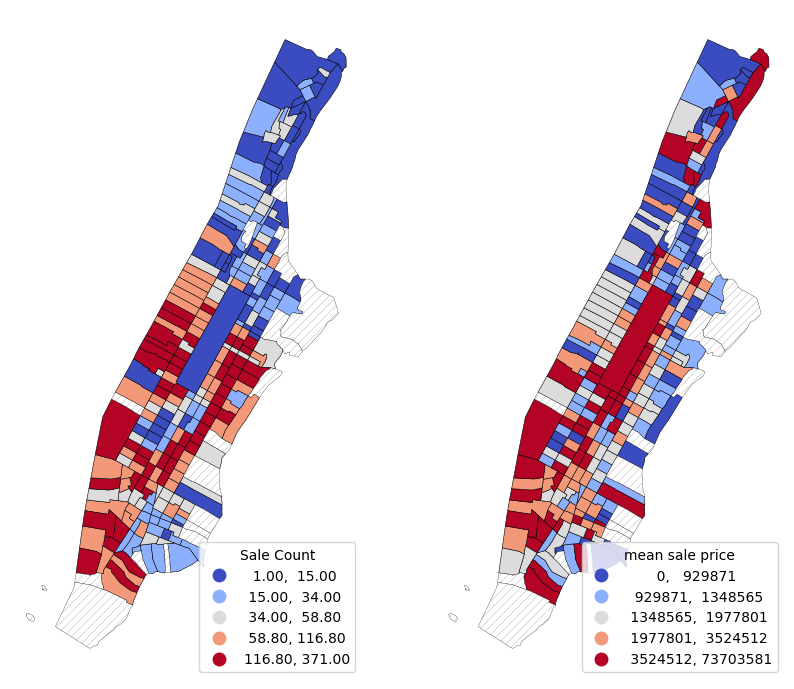

In [67]:
import matplotlib as mpl

# set the linewidth for hatch
mpl.rcParams['hatch.linewidth'] = 0.1

# create a plot
fig, ax = plt.subplots(1, 2, figsize = (10, 10))

# plot count
gdf_ManhanHousing[gdf_ManhanHousing['count'].notna()].plot(ax = ax[0], column = 'count', cmap = 'coolwarm', 
                                                 scheme='quantiles', k = 5,
                                                 edgecolor='black', linewidth=0.4,
                                                 legend = True, legend_kwds={'frameon': True, 
                                                                           'loc': 'lower right',
                                                                           'title': 'Sale Count',
                                                                           'title_fontsize': 10,
                                                                           'fontsize': 10})
gdf_ManhanHousing[gdf_ManhanHousing['count'].isna()].plot(ax = ax[0], 
                                              edgecolor='black', linewidth=0.2, color='white', hatch='////')
ax[0].axis('off')


# plot price
gdf_ManhanHousing[gdf_ManhanHousing['price'].notna()].plot(ax = ax[1], column = 'price', cmap = 'coolwarm', 
                                                 scheme='quantiles', k = 5,
                                                 edgecolor='black', linewidth=0.4,
                                                 legend = True, legend_kwds={'frameon': True, 
                                                                           'loc': 'lower right',
                                                                           'title': 'mean sale price',
                                                                           'title_fontsize': 10,
                                                                           'fontsize': 10, 
                                                                           "fmt": "{:.0f}"}) 
gdf_ManhanHousing[gdf_ManhanHousing['price'].isna()].plot(ax = ax[1], 
                                              edgecolor='black', linewidth=0.2, color='white', hatch='////')
ax[1].axis('off')

# save the figure
fig.savefig('manha_count_print_17.png', dpi = 200)

## 4. Spatial Overlay operations

Overlay analyses are GIS operations in which two or more vector layers are combined to produce new geometries. Typical overlay operations include union, intersection, and difference - named after the reslts of the combination of two layers. look at the function: [gpd.overlay()](https://geopandas.org/en/stable/docs/user_guide/set_operations.html)
![](https://geopandas.org/en/stable/_images/overlay_operations.png). 

- With `how='intersection'`, it returns only those geometries that are contained by both GeoDataFrames
- When using `how='union'`, all those possible geometries are returned
- `how='symmetric_difference'` is the opposite of 'intersection' and returns the geometries that are only part of one of the GeoDataFrames but not of both
- `how='difference'`: returns only the geometries that are in the first GeoDataFrame but NOT in the second.

In addition to Buffer and Overlay, the Geopandas package also includes a variety of geospatial processing tools, checking the user guide (https://geopandas.org/docs/user_guide/geometric_manipulations.html) to find the appropriate methods for your analysis. 



Let's say we want to identify public housing units that fall within an 800-meter radius of subway stations and those that do not.  We can use the intersection function in [gpd.overlay()](https://geopandas.org/en/stable/docs/user_guide/set_operations.html).
- create 800m buffer area of subway stations using `.buffer()`
- convert public houisng from polygon to point using `.centroid()`
- obtian the public housing within the 800m threshold using `intersection` option.
- obtain the public housing outside the 800m threshold using `difference` option.


In [84]:
# Step 0: preparation
gdf_station = gpd.read_file("Subway Stations.zip")
gdf_housing = gpd.read_file("NYCHA Public Housing Developments_20250219.zip")

gdf_station.to_crs(epsg = 3857, inplace = True)
gdf_housing.to_crs(epsg = 3857, inplace = True)

gdf_housing.rename(columns = {"developmen": "development"}, inplace = True)


In [90]:
# Step 1

# First, let's make our geometries

# Second, we already know the CRS
# This the same as the CRS of public housing data 

# Third, let's grab the data we want

# Now, let's put it all together using the GeoDataFrame constructor to create gdf_station_buffer 
gdf_station_buffer = gpd.GeoDataFrame(data = gdf_station,
                                      crs = gdf_station.crs, 
                                      geometry = gdf_station.geometry.buffer(800))
gdf_station_buffer.head(3)

,line,name,notes,objectid,url,geometry
0,4-6-6 Express,Astor Pl,"4 nights, 6-all times, 6 Express-weekdays AM s...",1.0,http://web.mta.info/nyct/service/,"POLYGON ((-8235848.235 4972605.859, -8235852.0..."
1,4-6-6 Express,Canal St,"4 nights, 6-all times, 6 Express-weekdays AM s...",2.0,http://web.mta.info/nyct/service/,"POLYGON ((-8236863.803 4970953.230, -8236867.6..."
2,1-2,50th St,"1-all times, 2-nights",3.0,http://web.mta.info/nyct/service/,"POLYGON ((-8235044.398 4977259.870, -8235048.2..."


Now, think about a senario: If a single point from `gdf_housing (public housing)` falls within multiple overlapping buffers in `gdf_station_buffer` (one-to-many), it will be duplicated in the result. We just want each housing development counted once. 

So, let us dissolve the buffer layer using [gdf.dissolve()](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.dissolve.html), which Dissolve geometries within groupby into single observation. 

The result is a single buffer layer - recall what we did in the GIS class when we do buffer - we choose "dissolve all"



In [97]:
# dissolve the gdf_station_buffer to make a sngle buffer layer. 
gdf_station_buffer = gdf_station_buffer.dissolve()

In [98]:
# Step 2: convert public houisng from polygon to point using .centroid() 
# .centroid returns the center point of an object.
gdf_housing.geometry = gdf_housing.centroid

In [101]:
# Step 3: obtian the public housing within the 800m threshold using intersection option.
# gdf_housing_point_yes
gdf_housing_point_yes = gpd.overlay(gdf_housing, gdf_station_buffer, how = "intersection")

In [102]:
# Step 4: obtian the public housing within the 800m threshold using difference option.
# gdf_housing_point_no
gdf_housing_point_no = gpd.overlay(gdf_housing, gdf_station_buffer  ,how = "difference")

<Axes: >

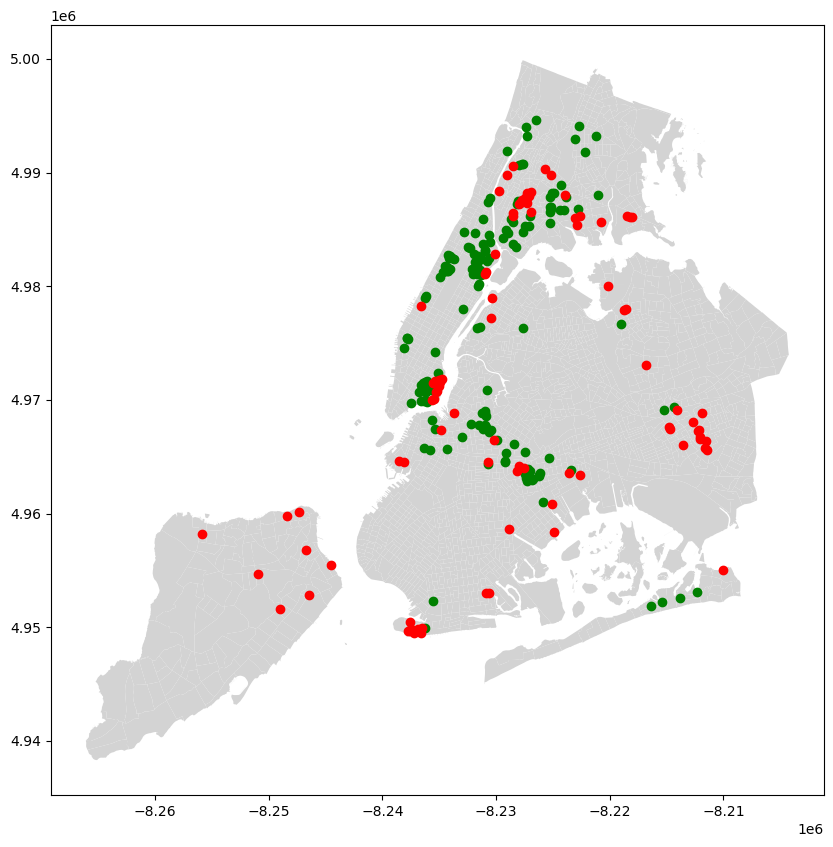

In [111]:
# let us plot the finding: 
fig, ax = plt.subplots(figsize = (10, 10))

# add a basemap
gdf_CT = gpd.read_file("2020 Census Tracts.zip")
gdf_CT = gdf_CT.to_crs(epsg = 3857)

# plot the results
gdf_CT.plot(ax = ax, color = "lightgrey")
gdf_housing_point_yes.plot(ax = ax, color = "green")
gdf_housing_point_no.plot(ax = ax, color = "red")

## In-class Exercises (due Feb 27th)

#### Areas not accessible by subway
Here, we are going to look at neighborhoods that are not accesible to a subway station

In [73]:
stations = gpd.read_file('Subway Stations.zip')


Let's look at the first 5 rows

In [ ]:
# Insert your code here


Create a 800 meter buffer around each station. If it didn't work, remember that buffers use the unit of measurement for the current CRS your geodataframe is in!

In [ ]:
stations_buffer = # Insert your code here

## We have to convert the buffer to a GeoDataFrame for the next step. 
## We also have to convert the buffer to the same crs as the neighborhoods.
stations_buffer = gpd.GeoDataFrame(geometry=stations_buffer).to_crs(4326)

Plot the results

In [ ]:
# Insert your code here


Now plot a spatial overlay so you can get the areas in each neighborhood not covered by a station buffer. 

In [ ]:
# Insert your code here
